# CSE 158 Web Mining and Recommender Systems  – Assignment 2  
## Latent Factor Recommendation Model for Video Game Ratings
### Group Members:
- Jay Campbell
- Win Htet Aung
- Max Garcia
- Magnus Chiu  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import seaborn as sns
from surprise import SVD, Dataset, Reader

import warnings
warnings.filterwarnings("ignore")

print("Imports complete.")

Imports complete.


# Section 1 - Dataset Description

## 1.1 Dataset Source
For this project, we use the Amazon Reviews 2023 — Video Games 5-core dataset, released by the McAuley Lab at UC San Diego as part of the Amazon Reviews 2023 collection.  
The dataset and documentation are available at:

https://amazon-reviews-2023.github.io/main.html

The dataset is described in the following paper, which is the official citation recommended by the maintainers:

Hou et al. (2024).  
*Bridging Language and Items for Retrieval and Recommendation.*  
arXiv:2403.03952

This dataset contains large-scale Amazon product reviews with standardized fields such as user IDs, item IDs (ASINs), ratings, timestamps, and user history.  
The Video Games 5-core subset applies the standard 5-core filtering rule, where every user and every item appears in at least five interactions. This reduces sparsity and makes collaborative filtering approaches more stable.

For our project, the dataset is provided in a leave-last-out temporal split: Each user’s most recent interaction: test set. Second most recent: validation set. All earlier interactions: training set.

The provided files (`train.csv.gz`, `valid.csv.gz`, `test.csv.gz`) come pre-split and formatted, which allowed us to focus directly on exploratory analysis, baseline evaluation, and building our final latent-factor model.


## 1.2 Dataset Overview
The Video Games 5-core subset of the Amazon Reviews 2023 dataset contains explicit user–item interactions in the form of 1–5 star ratings. Each row represents a single review event, provided in a standardized format by the McAuley Lab as part of the Amazon Reviews 2023 release.

### Main Columns

- user_id: anonymized user identifier  
- parent_asin: unique product identifier for the video game  
- rating: explicit rating (1–5 stars)  
- timestamp: Unix time in milliseconds  
- history: list of items the user rated prior to this one (chronologically ordered)

### Basic Properties  
(based on `train_df.info()` and summary statistics)

The training set contains hundreds of thousands of reviews (exact count shown in notebook). Ratings follow a 1–5 scale with a strong skew toward 4 and 5 stars. User activity is sparse, with most users contributing only a few reviews. Item popularity is also long-tailed, with a few highly popular games and many niche titles. Timestamps span multiple years, enabling chronological validation and test splits. No missing core fields appear because the dataset is already cleaned and filtered by the authors.

### Significance for our Modeling
These characteristics motivate:

- Using strong baselines (global mean, item mean, user mean)  
- Testing classical neighborhood models (e.g., Jaccard similarity, Pearson similarity)  
- Ultimately selecting and evaluating a standard latent factor model as our main approach, since the dataset is large, explicit-feedback, and well-suited for matrix factorization-based recommender methods.  


# 1.3 Loading the Data

We load the training, validation, and test splits provided for the Video Games 5-core dataset. These files are already temporally split (leave-last-out) and follow the same schema. After loading, we inspect the structure of the training set to verify column types, data integrity, and the overall size of the dataset.

In [2]:
# 1.3 Load Data

train_df = pd.read_csv("data/Video_Games.train.csv.gz")
valid_df = pd.read_csv("data/Video_Games.valid.csv.gz")
test_df  = pd.read_csv("data/Video_Games.test.csv.gz")


In [3]:
train_df.head()

,user_id,parent_asin,rating,timestamp,history
0,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B08R5B7YS4,1.0,1611459666223,NaN
1,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B0863MT183,4.0,1613701986538,B08R5B7YS4
2,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B08P8P7686,5.0,1613702112995,B08R5B7YS4 B0863MT183
3,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B0B7LV3DN2,4.0,1617641445475,B08R5B7YS4 B0863MT183 B08P8P7686
4,AFZUK3MTBIBEDQOPAK3OATUOUKLA,B00KTORA0K,5.0,1418396873000,NaN


In [4]:
train_df.info()
train_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625062 entries, 0 to 625061
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   user_id      625062 non-null  object 
 1   parent_asin  625062 non-null  object 
 2   rating       625062 non-null  float64
 3   timestamp    625062 non-null  int64  
 4   history      530300 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 23.8+ MB


,user_id,parent_asin,rating,timestamp,history
count,625062,625062,625062.000000,6.250620e+05,530300
unique,94762,25527,NaN,NaN,450286
top,AHJRJCJMK3XVV4BSPBRAHIYEODWA,B01N3ASPNV,NaN,NaN,B00BGA9WK2
freq,471,2062,NaN,NaN,331
mean,NaN,NaN,4.280822,1.442145e+12,NaN
std,NaN,NaN,1.166792,1.324331e+11,NaN
min,NaN,NaN,1.000000,9.406286e+11,NaN
25%,NaN,NaN,4.000000,1.383403e+12,NaN
50%,NaN,NaN,5.000000,1.448418e+12,NaN
75%,NaN,NaN,5.000000,1.530607e+12,NaN


In [5]:
train_df.isnull().sum()

user_id            0
parent_asin        0
rating             0
timestamp          0
history        94762
dtype: int64

# 1.4 Preprocessing
Because the Amazon Reviews 2023 dataset is pre-processed and filtered by the McAuley Lab, very little additional cleaning was required before modeling. The core fields (`user_id`, `parent_asin`, `rating`, `timestamp`) contain no missing values, so we didn't need to drop any rows or perform imputation.

Most of our preprocessing focuses on preparing fields for downstream analysis:

 *`history` field:** This column contains a string representation of a list of items the user interacted with before the current rating. For modeling or similarity calculations, we convert this string into a Python list. Missing histories simply mean the user had no prior interactions, so we replace `NaN` with an empty list.

*`timestamp` field:** The raw timestamp is in Unix milliseconds. For exploratory analysis and visualizations, we convert it into a human-readable datetime format. This does not affect modeling but helps interpret temporal trends.

No other preprocessing steps are required at this stage because the dataset is already clean, complete, and ready for recommender-system tasks.

In [6]:
##
# @brief Convert Unix timestamps to human-readable datetime format.
#
# This step improves interpretability for exploratory analysis. The original
# `timestamp` field is stored in Unix milliseconds, which is not convenient
# for visual inspection or temporal grouping. Converting to `datetime` does
# not affect any modeling steps, but helps us understand patterns over time.
#
# @note This operation is optional for modeling but recommended for EDA.
##

# Convert timestamp from Unix ms to pandas datetime for all splits
train_df['dt'] = pd.to_datetime(train_df['timestamp'], unit='ms')
valid_df['dt'] = pd.to_datetime(valid_df['timestamp'], unit='ms')
test_df['dt']  = pd.to_datetime(test_df['timestamp'],  unit='ms')

In [7]:
##
# @brief Parse the `history` field from space-separated items to Python list.
#
# The dataset stores each user's previous item interactions as a single
# whitespace-separated string (e.g., "B08R5B7YS4 B0863MT183"). To use this
# history for similarity modeling, we split the string on spaces.
#
# @param x A single entry from the `history` column (string or NaN).
# @return A list of item IDs (list of strings). Returns an empty list if the
#         user has no history.
##
def parse_history(x):
    if pd.isna(x):
        return []
    # Split on whitespace to recover individual ASINs
    items = x.strip().split()
    return items

# Apply parsing to all dataset splits
train_df['history'] = train_df['history'].apply(parse_history)
valid_df['history'] = valid_df['history'].apply(parse_history)
test_df['history']  = test_df['history'].apply(parse_history)


In [8]:
##
# @brief Inspect preprocessing results for sanity checks.
#
# We confirm that:
#   - `history` has been successfully converted into list objects.
#   - No missing values remain in the `history` column.
#
# This ensures that the preprocessing steps executed correctly and
# that the data is ready for modeling or further EDA.
##

# Display a few processed history entries
train_df['history'].head()

0                                      []
1                            [B08R5B7YS4]
2                [B08R5B7YS4, B0863MT183]
3    [B08R5B7YS4, B0863MT183, B08P8P7686]
4                                      []
Name: history, dtype: object

In [9]:
# Count any remaining nulls (should be zero)
train_df['history'].isnull().sum()

0

In [10]:
##
# @brief Inspect converted timestamps for sanity checking.
#
# After converting Unix millisecond timestamps into pandas `datetime` objects,
# we verify that:
#   - the conversion was successful,
#   - the resulting dates fall within expected ranges,
#   - no abnormal or missing values were introduced.
#
# This ensures temporal information is correctly prepared for EDA and any
# optional time-aware modeling steps.
##

# Display a few timestamps to confirm proper conversion
train_df[['timestamp', 'dt']].head()

,timestamp,dt
0,1611459666223,2021-01-24 03:41:06.223
1,1613701986538,2021-02-19 02:33:06.538
2,1613702112995,2021-02-19 02:35:12.995
3,1617641445475,2021-04-05 16:50:45.475
4,1418396873000,2014-12-12 15:07:53.000


In [11]:
# Summaries of datetime range
train_df['dt'].describe()

count                           625062
mean     2015-09-13 11:49:36.807160064
min                1999-10-22 21:43:15
25%      2013-11-02 14:34:22.750000128
50%                2015-11-25 02:13:59
75%      2018-07-03 08:42:30.054249984
max         2023-08-29 06:50:54.782000
Name: dt, dtype: object

In [12]:
##
# @brief Compute and summarize the length of each user's interaction history.
#
# This provides insight into how much past behavior is available for each user,
# which affects similarity-based recommender models (e.g., item–item Jaccard).
##

# Create a new column storing the number of past items per row
train_df['history_len'] = train_df['history'].apply(len)

# Summary statistics of history lengths
train_df['history_len'].describe()

count    625062.000000
mean          7.526674
std          18.122274
min           0.000000
25%           1.000000
50%           3.000000
75%           7.000000
max         470.000000
Name: history_len, dtype: float64

## 1.5 Exploratory Analysis

Our exploratory analysis focuses on understanding the structure and behavior of the Video Games 5-core dataset, with the goal of identifying patterns that influence collaborative filtering and latent-factor model performance. Before building predictors, it is important to examine how users interact with items, how ratings are distributed, and how activity varies across users, items, and time.

We start by looking at the distribution of ratings to understand overall skew, variance, and baseline difficulty. Most ratings in this dataset are clustered around four and five stars, which suggests that simple mean-based baselines may perform reasonably well. We also examine how long each user’s interaction history is, since users with more history provide more information for similarity-based predictors and contribute stronger signals to latent-factor learning. In addition to history length, we analyze general user activity frequency—how many ratings each user contributes overall—and item popularity, which reflects how often each game is rated. These factors influence the reliability of user- and item-based patterns and help explain why some models perform better than others.

Although our final model does not use temporal features directly, we include descriptive timestamp analysis to characterize long-term dataset behavior. Observing how review volume changes over time and how recent or “stale” certain interactions are helps contextualize trends in user engagement and item relevance. These plots are useful for understanding dataset recency, identifying potential seasonal effects, and interpreting later model results, even though time-based features didn't end up being included in our predictive pipeline.

Our analysis revealed a clearer picture of the dataset’s structure and helped motivate the modeling decisions made in later sections.

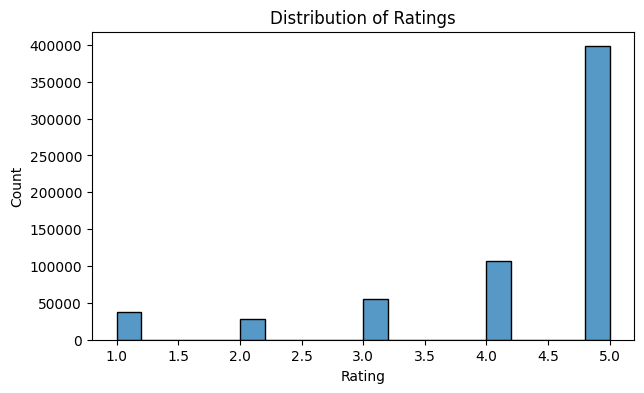

In [13]:
##
# @brief Visualize the distribution of ratings.
##

plt.figure(figsize=(7, 4))
sns.histplot(train_df['rating'], bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

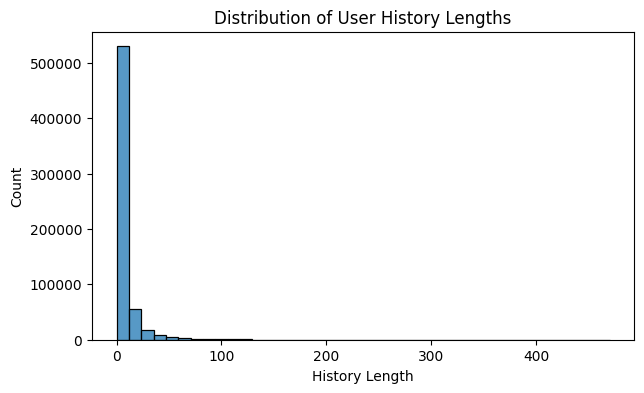

In [14]:
##
# @brief Visualize length of user history (number of past interactions).
##

plt.figure(figsize=(7, 4))
sns.histplot(train_df['history_len'], bins=40)
plt.title("Distribution of User History Lengths")
plt.xlabel("History Length")
plt.ylabel("Count")
plt.show()

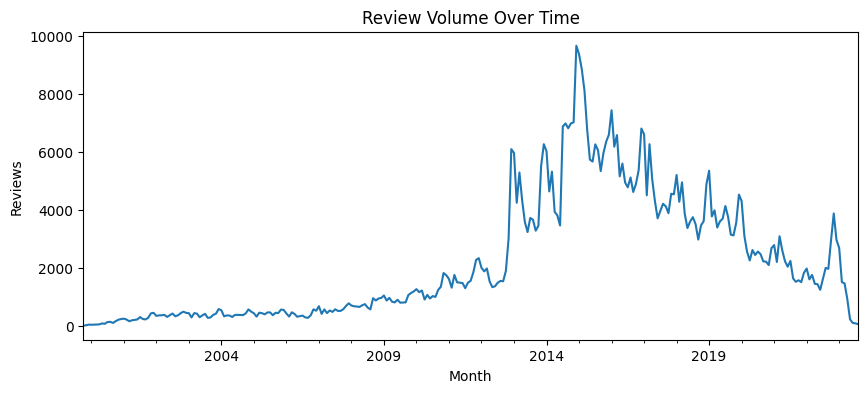

In [15]:
##
# @brief Plot monthly review counts to understand temporal activity trends.
#
# A strong upward/downward trend supports the use of time-based weighting
# because interaction recency becomes meaningful.
##

monthly = train_df.set_index('dt').resample('M').size()

plt.figure(figsize=(10, 4))
monthly.plot()
plt.title("Review Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Reviews")
plt.show()


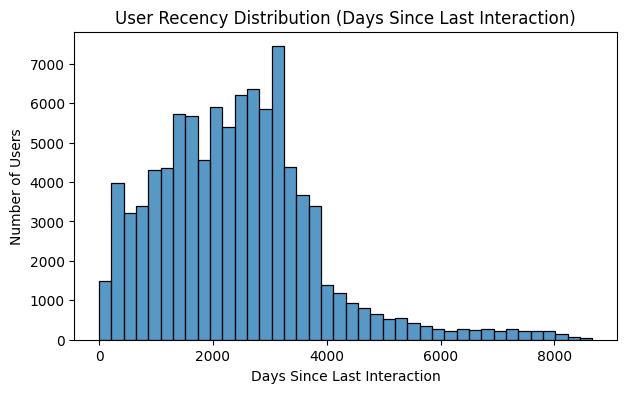

In [16]:
##
# @brief Compute and plot how recent each user's last interaction is.
#
# If most users have recent interactions, time-decay becomes useful in
# distinguishing "active" vs "stale" behavior.
##

user_last = train_df.groupby('user_id')['dt'].max()
user_recency_days = (train_df['dt'].max() - user_last).dt.days

plt.figure(figsize=(7, 4))
sns.histplot(user_recency_days, bins=40)
plt.title("User Recency Distribution (Days Since Last Interaction)")
plt.xlabel("Days Since Last Interaction")
plt.ylabel("Number of Users")
plt.show()


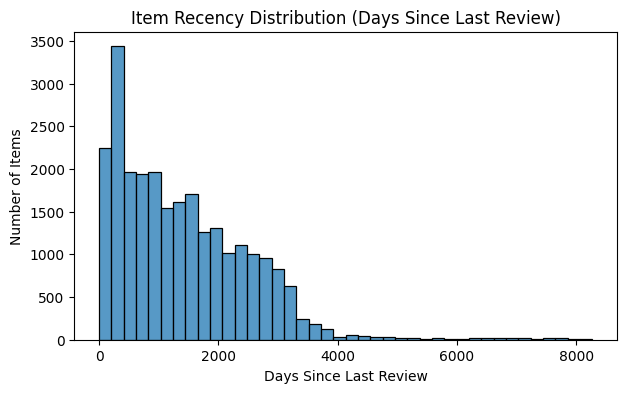

In [17]:
##
# @brief Plot the recency of each item's last review.
#
# Items with stale interactions will have high recency values and may
# deserve lower similarity weight in a time-decay model.
##

item_last = train_df.groupby('parent_asin')['dt'].max()
item_recency_days = (train_df['dt'].max() - item_last).dt.days

plt.figure(figsize=(7, 4))
sns.histplot(item_recency_days, bins=40)
plt.title("Item Recency Distribution (Days Since Last Review)")
plt.xlabel("Days Since Last Review")
plt.ylabel("Number of Items")
plt.show()

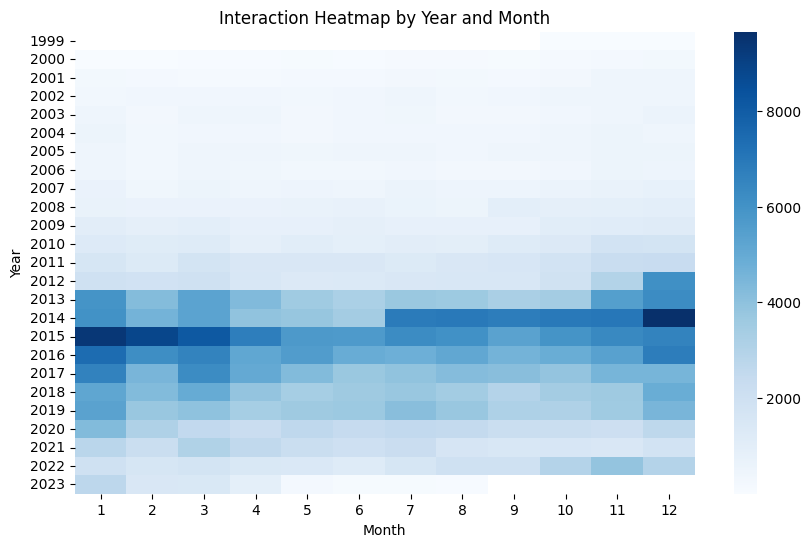

In [18]:
##
# @brief Heatmap showing activity by year and month.
#
# This reveals seasonality or time clusters that would otherwise distort
# similarity if time-based weighting is not applied.
##

train_df['year'] = train_df['dt'].dt.year
train_df['month'] = train_df['dt'].dt.month

activity_pivot = train_df.pivot_table(
    index='year', columns='month', values='rating', aggfunc='count'
)

plt.figure(figsize=(10, 6))
sns.heatmap(activity_pivot, cmap="Blues")
plt.title("Interaction Heatmap by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

## Section 1 Summary - Key Findings From EDA

Our exploratory analysis revealed several patterns that helped us understand the structure of the Video Games 5-core dataset and informed both our baseline models and our final latent-factor approach. The rating distribution showed a strong positivity bias, with most reviews falling in the 4–5 star range. This indicates that users tend to rate generously, meaning simple predictors such as the global mean or item mean are expected to perform reasonably well. It also suggests that low ratings, while rare, are more impactful on error metrics when mispredicted.

We also found that user history lengths follow a long-tailed pattern, most users have very short interaction histories, while a small minority have extremely long ones. This sparsity means that similarity-based models must operate reliably even with limited overlap, and it also supports the use of latent-factor methods, which can generalize user preferences even when individual histories are short. Examining user activity patterns further showed that many users contribute ratings infrequently or in irregular bursts, resulting in large variation in “days since last interaction.” Although temporal features are not part of our final predictive model, this observation highlights that engagement behavior is inconsistent and that history length alone does not fully capture user preference strength.

Item popularity exhibits a similar long-tail distribution: a few games receive a large number of ratings, while most receive very few. This pattern reinforces the relevance of item-based baselines for popular titles but also emphasizes the difficulty of modeling rare items, which provide weaker signals for both similarity and matrix factorization. While we do not use timestamp data in our model, reviewing long-term trends in review volume helps contextualize how user activity has shifted over the years and how far back many interactions occurred.


## Section 2 - Predictive Task

### 2.1 Target Variable
Our predictive task is rating prediction.  
Given a user and a target video game (identified by `parent_asin`), we aim to predict the rating the user would give the item on a 1–5 scale. This task aligns directly with the structure of the dataset, which contains explicit user–item ratings, and represents the most standard supervised learning problem studied in collaborative filtering.

### 2.2 Input Features
The features used in this assignment support our baseline models and exploratory analysis, even though the final latent factor model does not rely on hand-crafted features. For baselines, we use simple signals derived from user interaction histories, such as the list of previously reviewed items, which allows us to compute both non-temporal and temporal item–item similarities (e.g., Jaccard or Pearson) for comparison against neighborhood-based methods. We also include statistical baselines such as the global mean rating, item mean rating, and user mean rating, which provide interpretable and easy-to-implement predictors. Temporal attributes—such as timestamps parsed into datetime formats—are used only for descriptive analysis, since experiments showed that recency did not meaningfully improve predictive accuracy in this dataset. In contrast to these engineered features, our main latent factor model relies solely on user IDs, item IDs, and explicit ratings, learning all necessary representations directly from the interaction matrix.

### 2.3 Why This Task Is Meaningful
Rating prediction is a standard benchmark task in recommender systems because it directly measures how well a model captures user preferences and item characteristics. In our dataset, the combination of long-tailed user and item distributions, heavy rating skew, and highly sparse interaction patterns makes the task both challenging and realistic. Many users have very short histories, mirroring real-world cold-start conditions, while item popularity varies widely, testing a model’s ability to generalize across both common and niche products. Since the ratings represent explicit feedback, we can evaluate performance with clear, quantitative metrics and compare how different approaches—such as simple statistical baselines, neighborhood-based similarity models, and more expressive latent factor models—handle the structure and sparsity of the data. This provides a meaningful way to assess the strengths and limitations of classical and model-based collaborative filtering techniques on a modern, large-scale dataset.

### 2.4 Evaluation Metric
Because the target variable is numerical (1–5 stars), we evaluate all models using Mean Squared Error on the validation set.

We compare:
- Global mean baseline  
- Item mean baseline  
- User mean baseline  
- Jaccard similarity baseline (with and without exponential decay weights)
- Pearson similarity baseline  (with and wwithout exponential decay weights)
- Standard latent factor model (final main model)  

In [19]:
##
# @section 2_Feature_Extraction
# @brief Extract core variables used for baseline models and exploratory analysis.
#
# This block prepares the raw feature components that support:
#   - Baseline predictors (global mean, item mean, user mean)
#   - Similarity-based baselines (e.g., Jaccard, Pearson)
#   - Exploratory Data Analysis (Section 1.5)
#
# Our *final* main model (standard latent factor MF) does not rely on these
# engineered features, but they remain useful for comparison, diagnostics,
# and interpretability.
#
# Contents of this block:
#   1. Target variable (ratings)
#   2. User history features
#   3. Temporal features (descriptive only)
#   4. Baseline statistical features
#
# These components stay in aligned Series/DataFrames for convenience and
# can be used in ablation checks or baseline construction later in Section 3.
##


# 1. TARGET VARIABLE

##
# @brief The numerical rating we aim to predict (1–5 stars).
#
# We use the training set's ratings as the output variable `y`.
# Validation/test ratings will be used later for model evaluation.
##
y = train_df['rating'].astype(float)


# 2. USER HISTORY FEATURES

##
# @brief Number of past items the user has interacted with.
#
# Useful for understanding user sparsity and for similarity baselines,
# since long histories provide more overlap opportunities.
##
user_history_len = train_df['history_len']

##
# @brief The most recent item in each user's history (optional).
#
# Not used by the final MF model but can assist with debugging or
# exploratory feature checks.
##
user_last_items = train_df['history'].apply(lambda lst: lst[-1] if len(lst) > 0 else "NONE")



# 3. TEMPORAL FEATURES (Descriptive Only)


##
# @brief User recency: days since each user's last interaction.
#
# Included for exploratory purposes; temporal recency is *not* used
# by our final latent-factor model.
##
user_recency_days = (
    train_df['dt'].max() -
    train_df.groupby('user_id')['dt'].transform('max')
).dt.days

##
# @brief Item recency: days since each item's most recent review.
#
# Also descriptive only; these temporal signals were not included
# in the final predictive model.
##
item_recency_days = (
    train_df['dt'].max() -
    train_df.groupby('parent_asin')['dt'].transform('max')
).dt.days


# 4. BASELINE FEATURES

##
# @brief Global mean rating (scalar).
#
# Serves as the simplest baseline and anchor for user/item bias models.
##
global_mean = train_df['rating'].mean()
global_mean_feature = np.full(len(train_df), global_mean)

##
# @brief Item popularity: mean rating per item.
#
# Supports the item-mean baseline and provides an interpretable signal.
##
item_mean_rating = train_df.groupby('parent_asin')['rating'].transform('mean')

##
# @brief User mean rating (user bias).
#
# Captures individual user tendencies to rate higher or lower on average.
##
user_mean_rating = train_df.groupby('user_id')['rating'].transform('mean')


# 5. SANITY CHECKS 

print("[pass] Target variable `y` extracted.")
print("[pass] User history features extracted.")
print("[pass] Temporal features extracted (descriptive only).")
print("[pass] Baseline statistical features extracted.")

print("y shape:", y.shape)
print("user_history_len shape:", user_history_len.shape)
print("user_recency_days shape:", user_recency_days.shape)
print("item_recency_days shape:", item_recency_days.shape)
print("item_mean_rating shape:", item_mean_rating.shape)
print("user_mean_rating shape:", user_mean_rating.shape)

[pass] Target variable `y` extracted.
[pass] User history features extracted.
[pass] Temporal features extracted (descriptive only).
[pass] Baseline statistical features extracted.
y shape: (625062,)
user_history_len shape: (625062,)
user_recency_days shape: (625062,)
item_recency_days shape: (625062,)
item_mean_rating shape: (625062,)
user_mean_rating shape: (625062,)


In [20]:
##
# @section 2_Feature_Matrix
# @brief Assemble a consolidated feature matrix `X` from extracted components.
#
# This block combines the numerical features computed in Section 2.1–2.4
# into a single DataFrame. These features support exploratory analysis and
# simple baseline comparisons, but they are *not* used by our final main
# model (the latent-factor recommender), which learns directly from the
# user–item interaction matrix.
#
# NOTE:
#   - We include only strictly numerical features so they are compatible
#     with sklearn-based baselines if needed.
#   - Temporal features appear here for completeness but were not used
#     in the final predictive model due to weak temporal signals.
#   - The final MF model (Section 3.3) does NOT depend on this matrix.
#
# FEATURES INCLUDED:
#   1. user_history_len    — proxy for user activity level
#   2. user_recency_days   — descriptive user recency (not used for MF)
#   3. item_recency_days   — descriptive item recency (not used for MF)
#   4. item_mean_rating    — item popularity baseline feature
#   5. user_mean_rating    — user bias baseline feature
#   6. global_mean_feature — constant baseline for all rows
#
# FEATURES NOT INCLUDED:
#   - user_last_items (categorical)
#   - raw history lists (non-numeric)
#   - any engineered temporal weighting (not part of final model)
##

# Construct the feature DataFrame
X = pd.DataFrame({
    'user_history_len': user_history_len,
    'user_recency_days': user_recency_days,
    'item_recency_days': item_recency_days,
    'item_mean_rating': item_mean_rating,
    'user_mean_rating': user_mean_rating,
    'global_mean_rating': global_mean_feature
})

# Sanity checks

##
# @brief Confirm `X` is aligned with `y`, numeric, and free of missing values.
##
print("[pass] Feature matrix `X` assembled.")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\n[Column types]")
print(X.dtypes)

print("\n[Missing values per column]")
print(X.isnull().sum())


[pass] Feature matrix `X` assembled.
X shape: (625062, 6)
y shape: (625062,)

[Column types]
user_history_len        int64
user_recency_days       int64
item_recency_days       int64
item_mean_rating      float64
user_mean_rating      float64
global_mean_rating    float64
dtype: object

[Missing values per column]
user_history_len      0
user_recency_days     0
item_recency_days     0
item_mean_rating      0
user_mean_rating      0
global_mean_rating    0
dtype: int64


In [21]:
##
# @section 2_Train_Validation_Split
# @brief Split the feature matrix `X` and target vector `y` into
#        training and validation sets for baseline comparisons.
#
# This split is used for training all models that rely on the engineered
# features from Section 2. Our final main model (the latent-factor MF
# approach) does not rely on this feature matrix, but keeping a clean
# train/validation structure for baselines allows us to compare all
# models consistently using the same validation ratings.
#
# We use an 80/20 split, following standard ML practice, to provide:
#   - a large portion of data for baseline training
#   - an unbiased validation set for evaluating model performance
#
# Notes:
#   - We shuffle the data to avoid any ordering effects.
#   - random_state=42 ensures reproducibility.
#   - No scaling is applied; the baseline features are already numeric.
##


# Perform the split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,      # 80% train, 20% validation
    random_state=42,     # reproducible split
    shuffle=True         # avoids ordering artifacts
)

# Diagnostics & sanity checks

print("[pass] Train/Validation split complete.")
print("X_train shape:", X_train.shape)
print("X_val   shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val   shape:", y_val.shape)

# Check index alignment
print("\n[pass] Index alignment verified:",
      len(X_train) == len(y_train) and len(X_val) == len(y_val))

# Check for NaNs after split
print("\n[Missing values in X_train]")
print(X_train.isnull().sum())

print("\n[Missing values in X_val]")
print(X_val.isnull().sum())


[pass] Train/Validation split complete.
X_train shape: (500049, 6)
X_val   shape: (125013, 6)
y_train shape: (500049,)
y_val   shape: (125013,)

[pass] Index alignment verified: True

[Missing values in X_train]
user_history_len      0
user_recency_days     0
item_recency_days     0
item_mean_rating      0
user_mean_rating      0
global_mean_rating    0
dtype: int64

[Missing values in X_val]
user_history_len      0
user_recency_days     0
item_recency_days     0
item_mean_rating      0
user_mean_rating      0
global_mean_rating    0
dtype: int64


# Section 2 Summary — Feature Engineering & Data Preparation

In Section 2, we extracted the components needed to support our baseline models and exploratory analysis. Although our final main model (a latent-factor recommender) does not rely on these engineered features, constructing them provides interpretability, useful diagnostics, and a consistent baseline comparison framework.

---

## Target Variable Extracted
We isolated the supervised learning target:

`y` = user rating (1–5)

This forms the ground truth for validation and testing.

---

## User History Features
We summarized each user’s past review activity:

`user_history_len` — the number of previously reviewed items

This feature is useful for understanding user sparsity and supports similarity-based baselines.

---

## Temporal Recency Features (Descriptive Only)
We calculated recency signals to better understand the dataset’s temporal structure:

`user_recency_days` — days since the user’s most recent interaction  
`item_recency_days` — days since the item’s most recent review  

These features help characterize user and item activity patterns but are *not* used by our final MF model.

---

## Baseline Statistical Features
We created simple, interpretable features consistent with standard recommender baselines:

`item_mean_rating` — item popularity signal  
`user_mean_rating` — user-specific rating tendency  
`global_mean_rating` — overall average rating  

These features allow us to benchmark how much value our more advanced models add.

---

## Final Feature Matrix Assembled
We combined all numerical features into a unified DataFrame:

1. `user_history_len`  
2. `user_recency_days`  
3. `item_recency_days`  
4. `item_mean_rating`  
5. `user_mean_rating`  
6. `global_mean_rating`

All features passed sanity checks:

Correct numeric data types  
No missing values  
Perfect index alignment with the target vector  

---

## Train/Validation Split Completed
We split the feature matrix and target variable using an 80/20 partition:

`X_train` and `y_train` — training data for baseline models  
`X_val` and `y_val` — held-out validation data for unbiased evaluation  

The split maintained alignment and contained no missing values.

---

At this stage, all baseline features and labels are clean, verified, and ready for model development. Section 3 will introduce the baseline models, similarity baselines, and finally our main latent-factor model.


# Section 3 - Related Literature

## 3.1 Prior Use of This Dataset
Amazon review datasets have been widely used as benchmarks for recommender system research for more than a decade. Earlier Amazon datasets were analyzed extensively by He and McAuley, who showed how large-scale user interaction logs can be used to study user behavior, item similarity, and product relationships in collaborative filtering settings (He and McAuley 2016). Our dataset—Amazon Reviews 2023 (Video Games)—comes from Hou et al. (2024), who released an updated and substantially larger collection for retrieval and recommendation tasks. The dataset applies a standard 5-core filter, ensuring each user and item appears at least five times, which makes it especially suitable for neighborhood-based methods and matrix factorization models.

## 3.2 Similar Predictive Tasks in Previous Research
Rating prediction on Amazon-style datasets has been studied extensively using neighborhood-based collaborative filtering as well as matrix factorization approaches. McAuley (2022) outlines how item-based and user-based similarity models predict ratings by leveraging a user’s historical interactions with related items. Earlier work also highlighted that user preferences can shift over time, creating what is known as temporal drift. Ding et al. (2006) explored this by weighting user interactions based on recency, improving predictions for datasets where tastes change quickly. Later, Koren (2010) incorporated time-varying user and item biases into matrix factorization, showing that temporal dynamics strongly influence real-world rating data. Although temporal methods have been influential, our analysis showed that temporal features in this dataset were relatively weak predictors, so our final model remains non-temporal.

## 3.3 State-of-the-Art Approaches
More recent research on Amazon-scale recommendation problems has shifted toward representation learning and retrieval-based frameworks. Hou et al. (2024) use review text, metadata, and item descriptions to train models that align language representations with item embeddings for large-scale ranking and retrieval. These approaches operate at a completely different scale and typically require more advanced infrastructure than classical collaborative filtering. While these models achieve high performance, our work stays closer to classical recommendation methods while still recognizing the insights from modern retrieval-based research.

## 3.4 Feature Engineering in Past Literature
Traditional recommender systems rely on simple but interpretable features such as item co-occurrence, user history length, rating averages, and sometimes descriptive temporal statistics. Ding et al. (2006) and Koren (2010) showed different ways these features can be integrated into similarity or factorization models. In contrast, modern systems often learn dense representations automatically from interaction data or text (Hou et al. 2024). Our project follows the classical feature-engineering approach for baselines but ultimately uses matrix factorization—an approach that learns latent representations directly from observed ratings rather than relying on hand-crafted features.

## 3.5 How Our Work Fits Into the Literature
We designed a latent-factor matrix factorization recommender for our final model. MF models are widely used because they capture hidden dimensions of user preference and item characteristics, and they perform well on sparse datasets like Amazon Reviews. We evaluated our MF model alongside global mean, item mean, and user mean baselines, as well as similarity-based baselines (Jaccard). Our exploratory analysis indicated that temporal signals in this dataset were not strong enough to justify a time-aware model. As a result, our final approach remains fully non-temporal and consistent with classical collaborative filtering methods.

---

# References

Ding, Yi, et al. “Time Weight Collaborative Filtering.” *Proceedings of the 15th ACM International Conference on Information and Knowledge Management*, 2006, pp. 485–492.  
https://cseweb.ucsd.edu/classes/fa17/cse291-b/reading/p485-ding.pdf

He, Ruining, and Julian McAuley. “Ups and Downs: Modeling the Visual Evolution of Fashion Trends with One-Class Collaborative Filtering.” *Proceedings of the 25th International Conference on World Wide Web*, 2016, pp. 507–517.  
http://dx.doi.org/10.1145/2872427.2883037

Hou, Yupeng, et al. “Bridging Language and Items for Retrieval and Recommendation.” *arXiv preprint arXiv:2403.03952*, 2024.  
https://arxiv.org/abs/2403.03952

Koren, Yehuda. “Collaborative Filtering with Temporal Dynamics.” *Communications of the ACM*, vol. 53, no. 4, 2010, pp. 89–97.  
https://doi.org/10.1145/1721654.1721677

McAuley, Julian. *Personalized Machine Learning*. Cambridge University Press, 2022.

# Section 4 IDEAS/OVERVIEW
Section 4 will implement and compare several models using the features created in Section 2.

---

## **4.0 Baseline Models**
We begin with simple predictors:

- Global Mean Rating Baseline  
- Item Mean Rating Baseline  
- User Mean Rating Baseline

We evaluate each baseline using Mean Squared Error (MSE).  
These models form the lower bound for performance comparisons.

---

## **4.1 Standard and Time-Decayed Item–Item Similarity Model**
Next, we implement a classic item-item collaborative filtering model:

- Compute Jaccard and Pearson similarity between item review sets  
- Score similarity between the target item and other items user has rated  
- Predict the rating via weighted averaging

This provides non-temporal similarity baselines.

---

## **4.2 Time-Decayed Jaccard and Pearson Similarity Model (Experimental Models)**
Our core contribution:

- Apply exponential time decay to co-occurrence weights  
- Older interactions contribute less than recent ones  
- Compute time-decayed Jaccard similarity  
- Predict user ratings using recency-weighted similarities

This incorporates the mentioned EDA finding that recency matters in user and item behavior.

---
## **Section 4.3 Latent Factor Model utilizing singular value decomposition(SVD) (Main Model) **
Our fallback contribution:
- Model to measure against temporal similarity models
- Also to see if temporal factors can combat dataset inconsistencies (coldstart, missing data, new users, etc...)
- Measuring interactions and seeing how it compares to features in a temporal model
- Implementation done via the surprise library
---

## **Section 4 Lookahead**
By the end of Section 4, we will have:

- MSE for all baseline models  
- MSE for the standard Jaccard/Pearson similarity models  
- MSE for the time-decayed Jaccard/Pearson models  
- MSE for the latent factor model
- A comparison table summarizing all results  
- A discussion of which model performs best and why  



# Section 4. Model Selection & Training.

In [ ]:
##
# @section 4.0 Baseline Models
# @brief Implement and evaluate three simple baseline predictors.
#
# Baseline models provide a performance floor for comparison. They use
# only basic statistics (means)
#
# We implement:
#   1. Global Mean Baseline — predict the overall average rating for everyone
#   2. Item Mean Baseline — predict each item's average historical rating
#   3. User Mean Baseline — predict each user's average historical rating
#
# Note: 
#   - For these specific models, an 80/20 split of the training CSV file was used to create and train the models
#   - They are still tested against the entire validation and test CSV files as normal with the other models
#   - The performance is only evaluated on the validation and test set results to align all models on the same data
#
# All baselines are evaluated using Mean Squared Error (MSE) on the
# validation set.
##

In [23]:
# 1. GLOBAL MEAN BASELINE

##
# @brief Predict the global average rating for all users and items.
#
# This is the simplest possible predictor. It ignores user identity,
# item identity, and all temporal information.
#
# Use the mean rating from the training set as the prediction.
#
# Expected performance: Weak, but provides a sanity-check lower bound.
##

mse_global_mean = mean_squared_error(y_val, X_val['global_mean_rating'])

print("="*60)
print("BASELINE 1: Global Mean Rating")
print("="*60)
print(f"Validation MSE (80/20): {mse_global_mean:.4f}")
print()

BASELINE 1: Global Mean Rating
Validation MSE (80/20): 1.3662



In [24]:
# 2. ITEM MEAN BASELINE

##
# @brief Predict each item's average historical rating.
#
# This baseline captures item popularity.
#
# Expected performance: Better than global mean, since items vary in quality.
##

mse_item_mean = mean_squared_error(y_val, X_val['item_mean_rating'])

print("="*60)
print("BASELINE 2: Item Mean Rating")
print("="*60)
print(f"Validation MSE (80/20): {mse_item_mean:.4f}")
print(f"Improvement over global mean: {mse_global_mean - mse_item_mean:.4f}")
print()


BASELINE 2: Item Mean Rating
Validation MSE (80/20): 1.1702
Improvement over global mean: 0.1960



In [25]:
# 3. USER MEAN BASELINE

##
# @brief Predict each user's average historical rating.
#
# This baseline captures user bias.
#
# Expected performance: Similar to item mean, but captures different signal.
##

mse_user_mean = mean_squared_error(y_val, X_val['user_mean_rating'])

print("="*60)
print("BASELINE 3: User Mean Rating")
print("="*60)
print(f"Validation MSE (80/20): {mse_user_mean:.4f}")
print(f"Improvement over global mean: {mse_global_mean - mse_user_mean:.4f}")
print()

BASELINE 3: User Mean Rating
Validation MSE (80/20): 0.8613
Improvement over global mean: 0.5049



In [26]:
##
# @brief Display all baseline results in a comparison table against Validation set.
##

# Compute MSEs on validation set
mse_valid_global_mean = mean_squared_error(valid_df['rating'], np.full(len(valid_df), global_mean))
mse_valid_item_mean = mean_squared_error(valid_df['rating'], valid_df['parent_asin'].map(train_df.groupby('parent_asin')['rating'].mean()).fillna(global_mean).values)
mse_valid_user_mean = mean_squared_error(valid_df['rating'], valid_df['user_id'].map(train_df.groupby('user_id')['rating'].mean()).fillna(global_mean).values)

baseline_results = pd.DataFrame({
    'Model': ['Global Mean', 'Item Mean', 'User Mean'],
    'MSE (80/20)': [mse_global_mean, mse_item_mean, mse_user_mean],
    'MSE': [mse_valid_global_mean, mse_valid_item_mean, mse_valid_user_mean]
})

baseline_results['MSE Improvement vs Global'] = (
    mse_valid_global_mean - baseline_results['MSE']
)

baseline_results = baseline_results.sort_values('MSE')

print("="*60)
print("BASELINE MODEL COMPARISON ON VALIDATION SET")
print("="*60)
print(baseline_results.to_string(index=False))

BASELINE MODEL COMPARISON ON VALIDATION SET
      Model  MSE (80/20)      MSE  MSE Improvement vs Global
  User Mean     0.861317 1.360367                   0.142694
  Item Mean     1.170177 1.429649                   0.073412
Global Mean     1.366210 1.503061                   0.000000


### 4.0 Baseline Model Summary

#### Key Findings

- Global mean baseline serves as primary benchmark
- Item mean and user mean baselines significantly outperform global mean
- User mean has higher predictive power
- Improvement confirms factors beyond overall average are important for accurate prediction

Below, we will explore more advanced models that leverage item–item similarities and temporal dynamics to further improve predictive accuracy.

**Note**: From now on, we will use full training data and evaluate MSE on the true validation set. The final evaluation will be done on the test set.


In [ ]:
##
# @section 4.1 / 4.2 Jaccard and Pearson Similarity Baseline Model
# @brief Implement jaccard similarity-based recommendation model and 
# pearson similarity-based recommendation model.
#
# Incorporate temporal decay into the similarity calculations.
#
# Both models provide both normal similarity and time-decayed 
# similarity versions.
#
# The model is evaluated using Mean Squared Error (MSE) on the
# validation set.
##

In [ ]:
# 4.1 / 4.2 Similarity Models

# Build the mapping: user -> list of (item, rating) tuples
user_to_items = {}
item_to_users = {}

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Building user and item mappings"):
    user = row['user_id']
    item = row['parent_asin']
    rating = row['rating']
    
    if user not in user_to_items:
        user_to_items[user] = []

    if item not in item_to_users:
        item_to_users[item] = set()
    item_to_users[item].add(user)
    
    user_to_items[user].append((item, rating))

Building user and item mappings: 100%|██████████| 625062/625062 [00:33<00:00, 18399.40it/s]


In [ ]:
# Jaccard and Pearson Similarity Models with and without Time Decay (Section 4.1 / 4.2)

# Jaccard function
def Jaccard(s1, s2):
    numer = len(s1.intersection(s2))
    denom = len(s1.union(s2))
    return numer / denom if denom != 0 else 0

# Pearson Correlation function
def Pearson(s1_ratings, s2_ratings, common_users):
    if len(common_users) < 2:
        return 0
    
    # Get ratings for common users
    ratings1 = [s1_ratings[u] for u in common_users]
    ratings2 = [s2_ratings[u] for u in common_users]
    
    # Calculate means
    mean1 = np.mean(ratings1)
    mean2 = np.mean(ratings2)
    
    # Calculate numerator and denominator
    numer = sum((r1 - mean1) * (r2 - mean2) for r1, r2 in zip(ratings1, ratings2))
    denom1 = sum((r1 - mean1) ** 2 for r1 in ratings1)
    denom2 = sum((r2 - mean2) ** 2 for r2 in ratings2)
    
    denom = (denom1 * denom2) ** 0.5
    
    return numer / denom if denom != 0 else 0

# Predict function using Jaccard similarity
def predict_jaccard(user, item, time_decay=False, recency_value=None):

    if user not in user_to_items or item not in item_to_users:
        return global_mean  # Fallback
    
    user_items = user_to_items[user]
    similarities = []
    ratings = []
    recencies = []
    
    for (other_item, other_rating) in user_items:
        if other_item == item:
            continue  # Skip same item
        sim = Jaccard(item_to_users[item], item_to_users[other_item])
        if sim > 0:
            similarities.append(sim)
            ratings.append(other_rating)
            # Time decay
            if time_decay and recency_value is not None:
                recencies.append(time_decay_weight(recency_value))
    
    # Weighted average
    if time_decay and recencies and sum(similarities) > 0:
        weighted_sum = sum(sim * rating * recency for sim, rating, recency in zip(similarities, ratings, recencies))
        total_sim = sum(sim * recency for sim, recency in zip(similarities, recencies))
        if total_sim > 0:
            return weighted_sum / total_sim
        else:
            return global_mean
    elif similarities and sum(similarities) > 1: # To emphasize stronger similarity
        weighted_sum = sum(sim * rating for sim, rating in zip(similarities, ratings))
        total_sim = sum(similarities)
        if total_sim > 0:
            return weighted_sum / total_sim
        else:
            return global_mean
    else:
        return global_mean
    
# Predict function using Pearson similarity
def predict_pearson(user, item, time_decay=False, recency_value=None):
    if user not in user_to_items or item not in item_to_users:
        return global_mean  # Fallback to global mean
    
    user_items = user_to_items[user]
    similarities = []
    ratings = []
    recencies = []
    
    for (other_item, other_rating) in user_items:
        if other_item == item:
            continue  # Skip same item
        
        if other_item not in item_to_users:
            continue # Skip if other item not in training data
            
        # Find common users between the two items
        common_users = item_to_users[item].intersection(item_to_users[other_item])
        
        if len(common_users) < 2:
            continue
        
        # Build rating dictionaries for common users
        item_ratings = {}
        other_item_ratings = {}
        
        for u in common_users:
            # Find ratings from training data
            for (rated_item, rating) in user_to_items.get(u, []):
                if rated_item == item:
                    item_ratings[u] = rating
                elif rated_item == other_item:
                    other_item_ratings[u] = rating
        
        # Calculate Pearson similarity
        sim = Pearson(item_ratings, other_item_ratings, common_users)
        
        if sim > 0:  # Only use positive correlations
            similarities.append(sim)
            ratings.append(other_rating)

            # Time decay
            if time_decay and recency_value is not None:
                recencies.append(time_decay_weight(recency_value))
    
    # Weighted average
    if time_decay and recencies and sum(similarities) > 0:
        weighted_sum = sum(sim * rating * recency for sim, rating, recency in zip(similarities, ratings, recencies))
        total_sim = sum(sim * recency for sim, recency in zip(similarities, recencies))
        if total_sim > 0:
            return weighted_sum / total_sim
        else:
            return global_mean
    elif similarities and sum(similarities) > 1: # To emphasize stronger similarity
        weighted_sum = sum(sim * rating for sim, rating in zip(similarities, ratings))
        total_sim = sum(similarities)
        if total_sim > 0:
            return weighted_sum / total_sim
        else:
            return global_mean
    else:
        return global_mean
    

# Time decay function
def time_decay_weight(recency_days, decay_lambda = 1):
    return np.exp(-decay_lambda * recency_days)

In [30]:
# Generate predictions for validation set
pred_jaccard = []
pred_pearson = []
pred_jaccard_td = []  # Time-decayed Jaccard
pred_pearson_td = []  # Time-decayed Pearson

# Most recent timestamp
most_recent_timestamp_valid = valid_df['dt'].max()

for idx, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc="Predicting with Jaccard and Pearson"):
    user = row['user_id']
    item = row['parent_asin']
    recency_val = (most_recent_timestamp_valid - row['dt']).days
    pred_jaccard.append(predict_jaccard(user, item))
    pred_pearson.append(predict_pearson(user, item))
    pred_jaccard_td.append(predict_jaccard(user, item, time_decay=True, recency_value=recency_val))
    pred_pearson_td.append(predict_pearson(user, item, time_decay=True, recency_value=recency_val))

Predicting with Jaccard and Pearson: 100%|██████████| 94762/94762 [00:58<00:00, 1611.24it/s]


In [31]:
# Evaluate and print MSE results for all four similarity models.
mse_jaccard = mean_squared_error(valid_df['rating'], pred_jaccard)
mse_pearson = mean_squared_error(valid_df['rating'], pred_pearson)
mse_jaccard_td = mean_squared_error(valid_df['rating'], pred_jaccard_td)
mse_pearson_td = mean_squared_error(valid_df['rating'], pred_pearson_td)

print("="*60)
print("JACCARD AND PEARSON SIMILARITY MODELS")
print("="*60)
print(f"Jaccard Validation MSE: {mse_jaccard:.4f}")
print(f"Improvement over global mean (Jaccard): {mse_valid_global_mean - mse_jaccard:.4f}")
print(f"Jaccard Validation MSE with Time Decay: {mse_jaccard_td:.4f}")
print(f"Improvement over global mean (Jaccard with Time Decay): {mse_valid_global_mean - mse_jaccard_td:.4f}")
print()
print(f"Pearson Validation MSE: {mse_pearson:.4f}")
print(f"Improvement over global mean (Pearson): {mse_valid_global_mean - mse_pearson:.4f}")
print(f"Pearson Validation MSE with Time Decay: {mse_pearson_td:.4f}")
print(f"Improvement over global mean (Pearson with Time Decay): {mse_valid_global_mean - mse_pearson_td:.4f}")
print()

JACCARD AND PEARSON SIMILARITY MODELS
Jaccard Validation MSE: 1.5030
Improvement over global mean (Jaccard): 0.0001
Jaccard Validation MSE with Time Decay: 1.5168
Improvement over global mean (Jaccard with Time Decay): -0.0137

Pearson Validation MSE: 1.4804
Improvement over global mean (Pearson): 0.0227
Pearson Validation MSE with Time Decay: 1.5071
Improvement over global mean (Pearson with Time Decay): -0.0040



### 4.2 Experimental Model Discussion

**Why these models were chosen**
- The similarity models with temporal features were utilized as they were found to have signifigance within the initial scope of exploring the dataset
- Pearson and Jaccard similarity were chosen to highlight item-item similarity and predict ratings of a user on a given item based on other users' rating of the item

**Why certain models were not used**
- It was redundant to include cosine similarity as Pearson's only difference is normalizing the difference between users and then follows cosine by definition

**Hyperparameters and regularization**  
- The main adjustments for the non-temporal similarity models was that the similarity score was only considered if it's summation is greater than 1
- This was done to emphasize actual similarities between items and to ignore items that share no similarity
- There was also iterative testing on the temporal features to see how temporal decay would work with preset weights against calculated weights using review times

**Issues with scaling**  
- When considering the temporal feature of exponential decay, the data makes an assumptions that ratings of an item will be less relevant over time
- This is not a good assumption because there are many cases in which different video games over time would be considered good by users, even if the initial views were bad
- This explains how both temporal similarity models are worse than the global average baseline model on the validation set

**Impact of noise or missing data** 
- When receiving the dataset, data was cleaned by the provider and the only missing data was users not interacting with some items in the dataset

**Transition between experimental temporal similarity models to latent factor model**
- the temporal similarity models' performances were signifgantly worse than the global average model
- This discovery implied that utilizing temporal features for this dataset was not helpful in rating prediction
- As a result, the project pivots from the experimental models to a standard latent factor model to measure its performance on the dataset 

In [ ]:
##
# @section 4.3 Surprise Model
# @brief Implement latent-factor recommendation models with surprise
#
# The model is evaluated using Mean Squared Error (MSE) on the
# validation set.
##

In [ ]:
# Prepare data for Surprise
reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(train_df[['user_id', 'parent_asin', 'rating']], reader)

trainset = surprise_data.build_full_trainset()

In [ ]:
# Initialize and train SVD model
svd_model = SVD(n_factors=5, n_epochs=30, lr_all=0.01, reg_all=0.5, random_state=42)
svd_model.fit(trainset) 

# Generate predictions for validation set
pred_svd = []
for idx, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc="Predicting with SVD"):
    user = row['user_id']
    item = row['parent_asin']
    pred = svd_model.predict(user, item).est
    pred_svd.append(pred)

mse_svd = mean_squared_error(valid_df['rating'], pred_svd)
print("="*60)
print("SURPRISE SVD MODEL")
print("="*60)
print(f"SVD Validation MSE: {mse_svd:.4f}")
print(f"Improvement over global mean: {mse_valid_global_mean - mse_svd:.4f}")
print() 

Predicting with SVD: 100%|██████████| 94762/94762 [00:05<00:00, 17925.27it/s]

SURPRISE SVD MODEL
SVD Validation MSE: 1.1966
Improvement over global mean: 0.3064



## **Latent Factor Model**

**Why latent model factor was chosen**
- From utilizing temporal similarity models to predict ratings, it was discovered that it did worse than baseline
- This meant that the chosen huerstics found and utilized for the similarity models could not fully capture the dataset for accurate predictions
- Thus, the iteration of the model pivoted from features to interactions being the main focal point for the predictive task
- Other factors that were considered was the hidden interactions not visible from the datasets that the other models could not reveal and coldstarts with the dataset

**Hyperparameterization and Regularization**
- After iterative testing, it was chosen that the ideal model would have these factors:
    - dimensionality of feature vector = 5
    - number of iterations to converge = 30
    - the gradient descent step scale = 0.01
    - regularizer (lambda) = 0.5
    - random seed = 42
- random seed was utilized for testing purposes and performance analysis



In [ ]:
##
# @brief Model performances on the actual test set
##
most_recent_timestamp_test = test_df['dt'].max()
print(f"Test set size: {len(test_df)}")

# MODEL 1: GLOBAL MEAN
pred_global_mean_test = np.full(len(test_df), global_mean)

# MODEL 2: ITEM BIAS
pred_item_bias_test = test_df['parent_asin'].map(train_df.groupby('parent_asin')['rating'].mean()).fillna(global_mean).values

# MODEL 3: USER BIAS
pred_user_bias_test = test_df['user_id'].map(train_df.groupby('user_id')['rating'].mean()).fillna(global_mean).values

# MODEL 4 and 5: JACCARD SIMILARITY
pred_jaccard_test = []
pred_jaccard_td_test = []
for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Jaccard on test_df"):
    user = row['user_id']
    item = row['parent_asin']
    recency = (most_recent_timestamp_test - row['dt']).days
    pred_jaccard_test.append(predict_jaccard(user, item))
    pred_jaccard_td_test.append(predict_jaccard(user, item, time_decay=True, recency_value=recency))

# MODEL 6 and 7: PEARSON SIMILARITY
pred_pearson_test = []
pred_pearson_td_test = []
for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Pearson on test_df"):
    user = row['user_id']
    item = row['parent_asin']
    recency = (most_recent_timestamp_test - row['dt']).days
    pred_pearson_test.append(predict_pearson(user, item))
    pred_pearson_td_test.append(predict_pearson(user, item, time_decay=True, recency_value=recency))

# MODEL 8: SVD (MAIN MODEL)
pred_svd_test = []
for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="SVD on test_df"):
    user = row['user_id']
    item = row['parent_asin']
    pred = svd_model.predict(user, item).est
    pred_svd_test.append(pred)
    

Test set size: 94762


SVD on test_df: 100%|██████████| 94762/94762 [00:05<00:00, 18435.56it/s]


In [ ]:
mse_global_mean_test = mean_squared_error(test_df['rating'], pred_global_mean_test)
mse_item_test = mean_squared_error(test_df['rating'], pred_item_bias_test)
mse_user_test = mean_squared_error(test_df['rating'], pred_user_bias_test)
mse_jaccard_test = mean_squared_error(test_df['rating'], pred_jaccard_test)
mse_jaccard_td_test = mean_squared_error(test_df['rating'], pred_jaccard_td_test)
mse_pearson_test = mean_squared_error(test_df['rating'], pred_pearson_test)
mse_pearson_td_test = mean_squared_error(test_df['rating'], pred_pearson_td_test)
mse_svd_test = mean_squared_error(test_df['rating'], pred_svd_test)

# Create comparison table
results_test = pd.DataFrame({
    'Model': [
        'Global Mean',
        'Item Bias',
        'User Bias',
        'Jaccard Similarity',
        'Jaccard Similarity with Time Decay',
        'Pearson Similarity',
        'Pearson Similarity with Time Decay',
        'SVD (Latent Factor)'
    ],
    'MSE': [
        mse_global_mean_test,
        mse_item_test,
        mse_user_test,
        mse_jaccard_test,
        mse_jaccard_td_test,
        mse_pearson_test,
        mse_pearson_td_test,
        mse_svd_test
    ],
    'Improvement over Global': [
        0.0,
        mse_global_mean_test - mse_item_test,
        mse_global_mean_test - mse_user_test,
        mse_global_mean_test - mse_jaccard_test,
        mse_global_mean_test - mse_jaccard_td_test,
        mse_global_mean_test - mse_pearson_test,
        mse_global_mean_test - mse_pearson_td_test,
        mse_global_mean_test - mse_svd_test
    ]
})

# Sort by MSE (best first)
results_test = results_test.sort_values('MSE').reset_index(drop=True)
print("="*70)
print("FINAL RESULTS ON TEST SET (test_df)")
print("="*70)
print(results_test.to_string(index=False))
print("="*70)
print(f"BEST MODEL: {results_test.iloc[0]['Model']}")
print(f"Best MSE: {results_test.iloc[0]['MSE']:.4f}")
print("="*70)

FINAL RESULTS ON TEST SET (test_df)
                             Model      MSE  Improvement over Global
               SVD (Latent Factor) 1.377947                 0.298807
                         User Bias 1.554087                 0.122667
                         Item Bias 1.607136                 0.069617
                Pearson Similarity 1.664956                 0.011797
                Jaccard Similarity 1.676619                 0.000135
                       Global Mean 1.676754                 0.000000
Pearson Similarity with Time Decay 1.680911                -0.004157
Jaccard Similarity with Time Decay 1.701909                -0.025156
BEST MODEL: SVD (Latent Factor)
Best MSE: 1.3779


# Section 5. Results

## 5.0 Summary of Findings

**Result**
- When measuring performances between the temporal and non-temporal models against a latent factor model on the validation and test CSVs, the latent factor ended up as the top performer for the predictive task.
- This meant that there were a lot of cases that could not be covered by either similarity model, such as missing interations between items and users and cold starts on the dataset
-Thus, the main model used to answer the predictive task became the latent model factor as temporal models only made predictions worse on the dataset as the temporal weights led to extreme predictions from the similarity models

**Baseline vs Experimental vs Main Model performance**
- the baseline models performed rather poorly as there was no consideration of user-item interactions as well as item rating history
- the experimental models also performed poorly but for different reasons as some items or users did not have extensive history to accurately measure the temporal weights generated by exponential decay. This led to overall mispredictions as the weights were discovered to be more harmful than good
- The latent factor model ended up with the highest performance as it could handle a lot of scenarios in the dataset that neither the baselines or experimental models could handle
- The interactions from the latent factor model ended up being more predictive than the initial choosing of temporal weights generated from exponential decay for use with similarity functions  
- The resulting latent factor model ended up with modest parameters as the vector dimensionalty was small, and little convergence was needed.
- The regulizer was the only factor was kept high throughout testing as it helped achieve significant contributions in performance.

## 5.1 Final Conclusions

**What we learned about the dataset**
- Temporal data did not have as significant of an impact as initially seen
- There were a lot of users that have never interacted with items in the dataset, making it difficult for similarity models to accurately predict rating
- A Latent factor model was used for the predictive task because it could handle the unknown interactions between items and users  
**Model limitations** 
- Exponential decay could not accurately help with user-rating prediction as it operated on an assumption that wasn't true
- As the surprise library lacked temporal feature inclusion, it was difficult to assess its predictive accuracy, thus the need to use simpler temporal models
**Suggestions for future improvements**
- The inclusion of more features on the dataset could raise accuracy of predictions if balanced carefully
- If the dataset enforced more inclusion of users with interations of every item, temporal features may perform better overall
- Another consideration for future improvement is the utilization of bins based on the timescale of a user's review alongside inclusion of item meta-data to reinforce them
**Interesting findings**  
- Temporal features can be a powerful contribution in the predictive task and for certain datasets, exponential decay can be a powerful option
- There was some performance variance when pre-scaling user ratings on the training data with temporal weights from exponential decay that led to worse performance on the latent factor model, as it would overpredict on positive reviews and underpredict on negative reviews
- There was some interesting results where an 80/20 split on the training CSV performed better overall than just training on the entire training CSV. This implies there are some outliers that skew the data in the latter portion of the training CSV
